In [ ]:
import sys
sys.path.append('../src')

import numpy as np
from PIL import ImageFont
from matplotlib import pyplot as plt
from palette.symbol2value import get_asciis, make_symbol2value_map

In [5]:
FONT = ImageFont.truetype("../fonts/FiraCode-Regular.ttf", 11)
SYMBOLS = get_asciis()

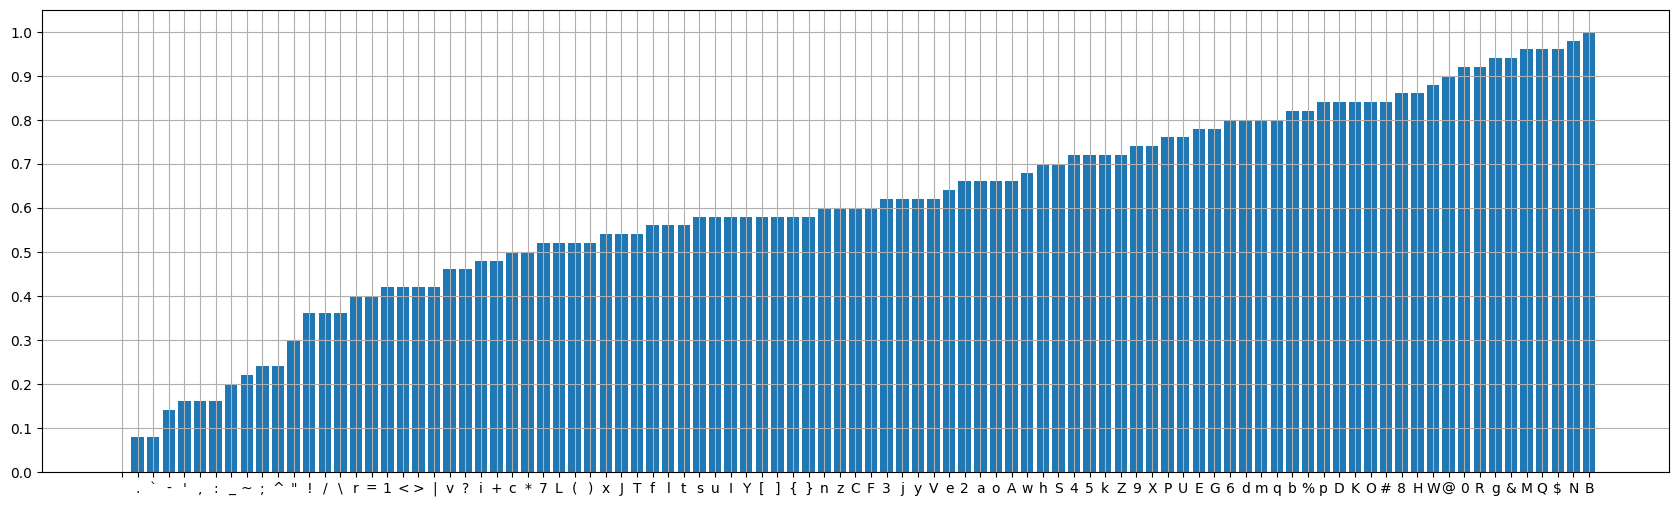

In [6]:
symbol2brightness = make_symbol2value_map(
    symbols=SYMBOLS,
    font=FONT,
    val_height=1,
    val_width=1,
    normalize=True)
brightness = [(s, b[0][0]) for s, b in symbol2brightness.items()]
brightness = sorted(brightness, key=lambda s_b: s_b[1])
plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.bar([sb[0] for sb in brightness], [sb[1] for sb in brightness])
plt.grid()

[[' '], ['.', '`'], ["'", ',', '-', ':'], ['_', '~'], [';', '^'], ['!', '"'], ['1', 'r', '/', '<', '=', '>', '\\'], ['i', 'v', '+', '?', '|'], ['7', 'c', 'f', 'l', 't', 'x', 'J', 'L', 'T', '(', ')', '*'], ['3', 'j', 'n', 's', 'u', 'y', 'z', 'C', 'F', 'I', 'V', 'Y', '[', ']', '{', '}'], ['2', 'a', 'e', 'h', 'o', 'w', 'A', 'S'], ['4', '5', '9', 'k', 'P', 'U', 'X', 'Z'], ['6', 'b', 'd', 'm', 'p', 'q', 'E', 'G', '%'], ['8', 'D', 'H', 'K', 'O', 'W', '#', '@'], ['0', 'g', 'Q', 'R', '$', '&'], ['B', 'M', 'N']]


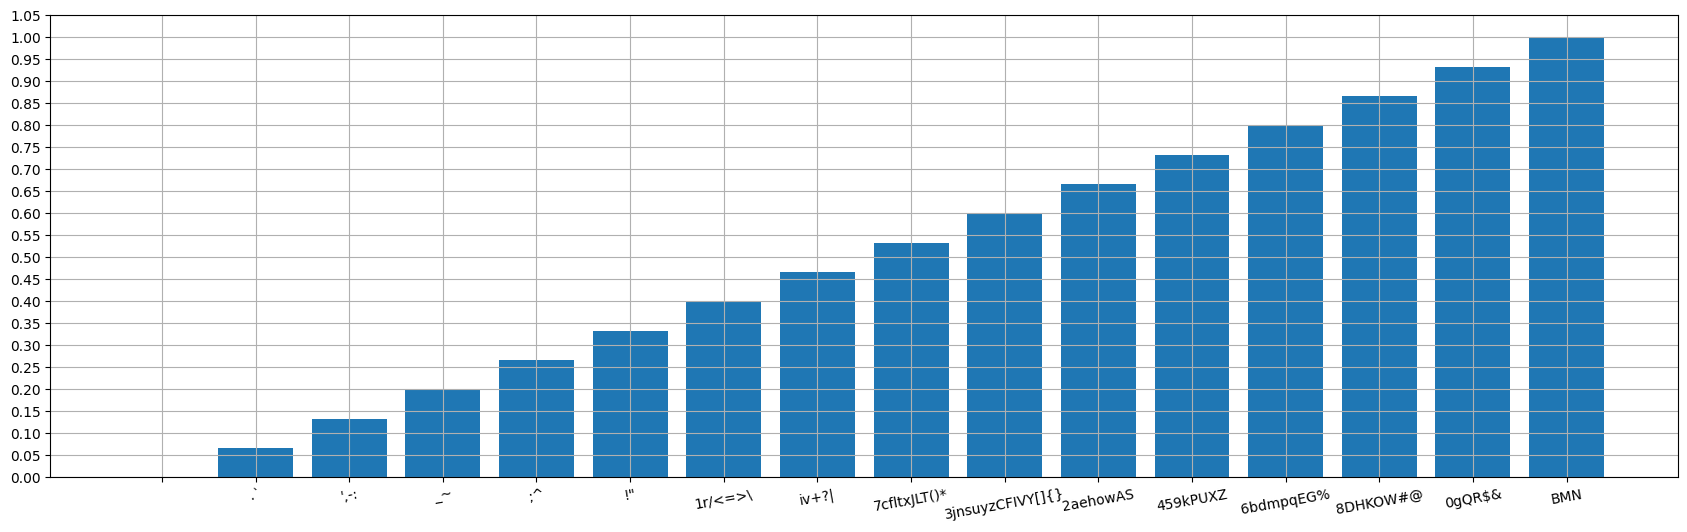

In [12]:
from converters.tile.bin_1d import make_1d_bin_palette

bins, mean_bin_brs = make_1d_bin_palette(SYMBOLS, FONT, bins=16, normalize=True)
print(bins)

plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0, 1.1, 0.05))
plt.xticks(rotation=10)
plt.bar([''.join(l) for l in bins], mean_bin_brs)
plt.grid()

In [ ]:
from modules.palette_generation import add_ansi_256_colors_grayscale


GS_SYMBOLS = add_ansi_256_colors_grayscale(get_asciis(), 4)

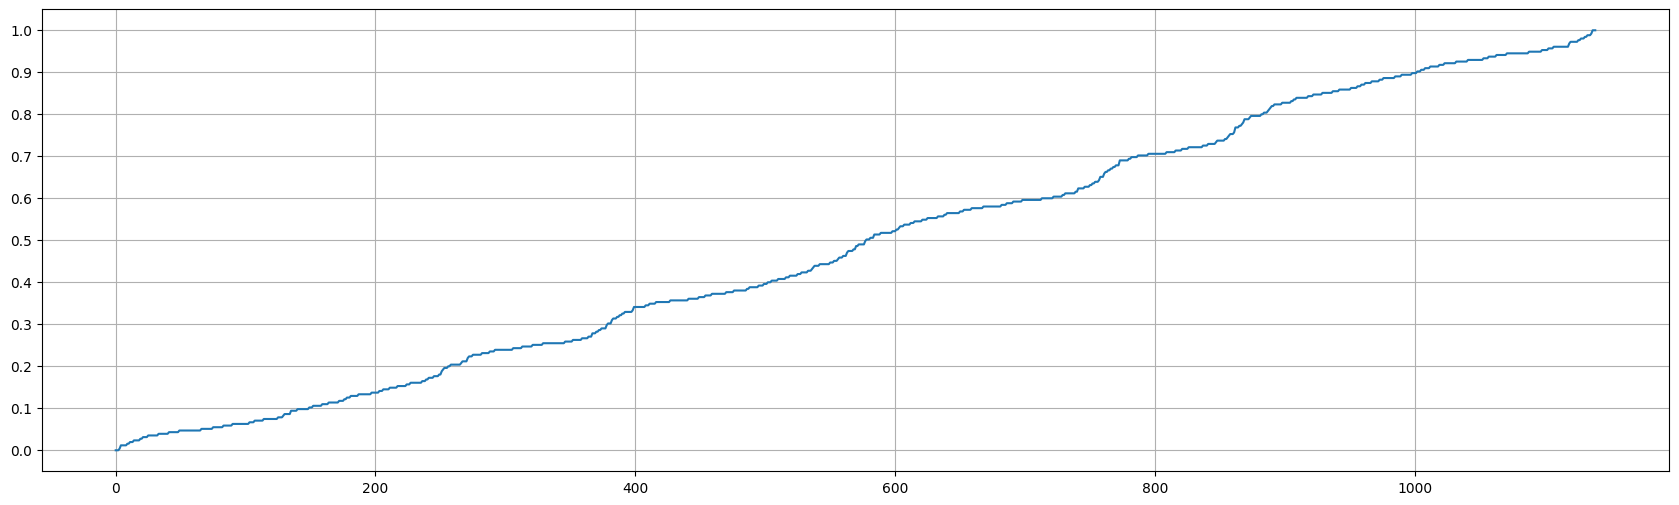

In [ ]:
symbol2brightness = make_symbol2value_map(
    symbols=GS_SYMBOLS,
    font=FONT,
    val_height=1,
    val_width=1,
    normalize=True)
brightness = [(s, b[0][0]) for s, b in symbol2brightness.items()]
brightness = sorted(brightness, key=lambda s_b: s_b[1])
plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.plot([sb[1] for sb in brightness])
plt.grid()

[90, 88, 73, 70, 62, 87, 68, 40, 62, 106, 27, 85, 31, 78, 96, 77]


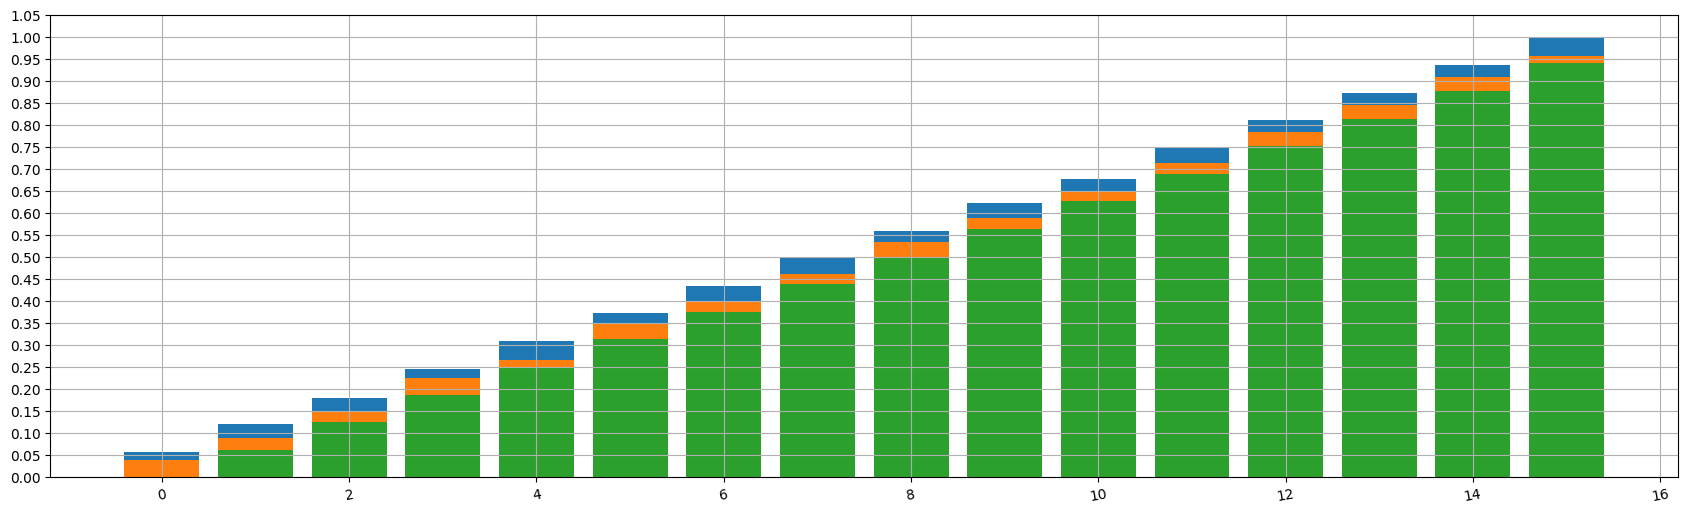

In [ ]:
bins, mean_bin_brs = make_1d_bin_palette(GS_SYMBOLS, FONT, bins=16, normalize=True)
print([len(bin) for bin in bins])
min_bin_brs = [symbol2brightness[min(bin, key=lambda s: symbol2brightness[s])][0][0] for bin in bins]
max_bin_brs = [symbol2brightness[max(bin, key=lambda s: symbol2brightness[s])][0][0] for bin in bins]

plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0, 1.1, 0.05))
plt.xticks(rotation=10)
plt.bar(np.arange(len(bins)), max_bin_brs)
plt.bar(np.arange(len(bins)), mean_bin_brs)
plt.bar(np.arange(len(bins)), min_bin_brs)
plt.grid()